# 07 — Historical QF Advancement Modelling

**ML question:** Can group-stage passing-network patterns *learned from one World Cup* rank teams by quarterfinal likelihood in a *different* World Cup?

This is a different question from the Mann-Whitney analyses in notebooks 05/16/17, which ask whether individual features differ between QF and non-QF teams within one tournament. This notebook asks whether a model trained on one tournament's full feature combination transfers to another — see "Relationship to the Statistical Association Analysis" below for the distinction.

**Framing:** This is an exploratory ranking/profile model, not a match-outcome predictor or a calibrated probability forecaster. **Random Forest is the primary model**; Logistic Regression is kept only as a simple linear baseline for comparison.

**Backtesting strategy (leave-one-tournament-out, both directions):**
- Direction 1: train on 2018 group-stage team profiles (32 teams), test on 2022 (32 teams)
- Direction 2: train on 2022 group-stage team profiles (32 teams), test on 2018 (32 teams)

The unit of analysis is **one aggregated group-stage profile per team** — never team-match rows.

> **Small-sample caution:** each model is trained on only 32 teams, including only 8 quarterfinalists. Performance estimates can be highly sensitive to individual teams and tournament-specific conditions. Treat these models as exploratory cross-tournament validation, not production-level prediction systems.

**Input:** `data/processed/worldcup_group_stage_team_profiles.csv`
**Output:** `outputs/tables/cross_tournament_qf_validation.csv`

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics         import roc_auc_score, roc_curve

PROC_DIR  = Path('../data/processed')
TABLE_DIR = Path('../outputs/tables')
FIG_DIR   = Path('../outputs/figures')
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

combined = pd.read_csv(PROC_DIR / 'worldcup_group_stage_team_profiles.csv')

print(f'Combined dataset: {combined.shape}')
print(combined.groupby(['tournament_year','reached_qf']).size().to_string())

Combined dataset: (64, 18)
tournament_year  reached_qf
2018             0             24
                 1              8
2022             0             24
                 1              8


## 1. Data Validation

In [2]:
# ── Validate the group-stage team-profile input before any modeling ───────
print('── Team-profile validation ────────────────────────────────────')
problems = []

for year in [2018, 2022]:
    sub       = combined[combined['tournament_year'] == year]
    n_teams   = sub['team'].nunique()
    n_rows    = len(sub)
    n_qf      = int((sub['reached_qf'] == 1).sum())
    n_non_qf  = int((sub['reached_qf'] == 0).sum())
    n_dupe    = sub['team'].duplicated().sum()

    print(f'{year}:')
    print(f'  teams        : {n_teams}   (expected 32)')
    print(f'  rows         : {n_rows}   (expected 32, one per team)')
    print(f'  QF teams     : {n_qf}   (expected 8)')
    print(f'  non-QF teams : {n_non_qf}   (expected 24)')
    print(f'  duplicate teams: {n_dupe}   (expected 0)')

    if n_teams != 32:  problems.append(f'{year}: expected 32 teams, got {n_teams}')
    if n_rows != 32:   problems.append(f'{year}: expected 32 rows, got {n_rows}')
    if n_qf != 8:      problems.append(f'{year}: expected 8 QF teams, got {n_qf}')
    if n_non_qf != 24: problems.append(f'{year}: expected 24 non-QF teams, got {n_non_qf}')
    if n_dupe != 0:    problems.append(f'{year}: {n_dupe} duplicate team rows found')

print('──────────────────────────────────────────────────────────────')
if problems:
    raise AssertionError('Data validation failed:\n' + '\n'.join(problems))
print('All validation checks passed for both tournaments.')

── Team-profile validation ────────────────────────────────────
2018:
  teams        : 32   (expected 32)
  rows         : 32   (expected 32, one per team)
  QF teams     : 8   (expected 8)
  non-QF teams : 24   (expected 24)
  duplicate teams: 0   (expected 0)
2022:
  teams        : 32   (expected 32)
  rows         : 32   (expected 32, one per team)
  QF teams     : 8   (expected 8)
  non-QF teams : 24   (expected 24)
  duplicate teams: 0   (expected 0)
──────────────────────────────────────────────────────────────
All validation checks passed for both tournaments.


## 2. Features and Cross-Tournament Split

In [3]:
FEATURES = [
    'avg_completed_passes',
    'avg_network_density',
    'avg_final_third_entries',
    'avg_final_third_entries_per_100_passes',
    'avg_connections_per_100_passes',
    'avg_passes_per_connection',
    'avg_top_player_reliance',
    'std_network_density',
    'std_completed_passes',
]

TARGET = 'reached_qf'

# All features are group-stage-only aggregates (avg_*/std_* of group-stage matches) —
# no post-group-stage outcome information (e.g. stage_reached) is included.
assert 'stage_reached' not in FEATURES and TARGET not in FEATURES, \
    'A future-outcome column leaked into the feature list.'

train = combined[combined['tournament_year'] == 2018].copy()
test  = combined[combined['tournament_year'] == 2022].copy()

X_train = train[FEATURES].fillna(train[FEATURES].median())
y_train = train[TARGET]

# Missing test values filled using TRAINING-set statistics only — no leakage.
X_test  = test[FEATURES].fillna(train[FEATURES].median())
y_test  = test[TARGET]

# Standardize features (Logistic Regression is sensitive to scale). Fit on
# training data only, then applied to test — no test-data leakage into scaling.
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Training set : {X_train.shape}  |  QF+ = {y_train.sum()}, non-QF = {(y_train==0).sum()}')
print(f'Test set     : {X_test.shape}   |  QF+ = {y_test.sum()}, non-QF = {(y_test==0).sum()}')
print()
print('Features:', FEATURES)

Training set : (32, 9)  |  QF+ = 8, non-QF = 24
Test set     : (32, 9)   |  QF+ = 8, non-QF = 24

Features: ['avg_completed_passes', 'avg_network_density', 'avg_final_third_entries', 'avg_final_third_entries_per_100_passes', 'avg_connections_per_100_passes', 'avg_passes_per_connection', 'avg_top_player_reliance', 'std_network_density', 'std_completed_passes']


In [4]:
# Quick feature correlation check — helps spot redundant features
corr = X_train[FEATURES].corr().round(2)
print('Feature correlation matrix (training set):')
corr

Feature correlation matrix (training set):


,avg_completed_passes,avg_network_density,avg_final_third_entries,avg_final_third_entries_per_100_passes,avg_connections_per_100_passes,avg_passes_per_connection,avg_top_player_reliance,std_network_density,std_completed_passes
avg_completed_passes,1.00,0.83,0.91,-0.48,-0.93,0.98,0.51,-0.33,0.13
avg_network_density,0.83,1.00,0.73,-0.47,-0.79,0.78,0.40,-0.28,0.20
avg_final_third_entries,0.91,0.73,1.00,-0.09,-0.78,0.86,0.31,-0.39,0.05
avg_final_third_entries_per_100_passes,-0.48,-0.47,-0.09,1.00,0.60,-0.50,-0.52,0.05,-0.35
avg_connections_per_100_passes,-0.93,-0.79,-0.78,0.60,1.00,-0.95,-0.58,0.30,-0.20
avg_passes_per_connection,0.98,0.78,0.86,-0.50,-0.95,1.00,0.56,-0.26,0.14
avg_top_player_reliance,0.51,0.40,0.31,-0.52,-0.58,0.56,1.00,-0.09,0.33
std_network_density,-0.33,-0.28,-0.39,0.05,0.30,-0.26,-0.09,1.00,-0.08
std_completed_passes,0.13,0.20,0.05,-0.35,-0.20,0.14,0.33,-0.08,1.00


## 3. Baseline — Logistic Regression

Logistic Regression provides a simple linear baseline against which the nonlinear Random
Forest model (the primary model in this notebook, see Section 4) can be compared. L2
regularisation (C=0.5) reduces overfitting on the small training set. Cross-validation on
2018 gives an estimate of how the model generalises *within* 2018, before looking at the
2022 test set.

In [5]:
lr = LogisticRegression(C=0.5, max_iter=1000, random_state=42)

# 5-fold CV on training set (estimate of generalisation)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aucs = cross_val_score(lr, X_train_s, y_train, cv=cv, scoring='roc_auc')
print(f'5-fold CV ROC-AUC on 2018 training set (baseline model):')
print(f'  {cv_aucs.round(3)}  →  mean = {cv_aucs.mean():.3f}  std = {cv_aucs.std():.3f}')
print()

# Fit on full 2018, predict on 2022
lr.fit(X_train_s, y_train)
lr_proba = lr.predict_proba(X_test_s)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)
print(f'Baseline (Logistic Regression) test ROC-AUC (2022) : {lr_auc:.3f}')

5-fold CV ROC-AUC on 2018 training set (baseline model):
  [0.2   0.6   0.6   0.2   0.375]  →  mean = 0.395  std = 0.179

Baseline (Logistic Regression) test ROC-AUC (2022) : 0.656


In [6]:
# Logistic Regression coefficients — direction and magnitude (baseline model only)
coef_df = pd.DataFrame({
    'feature':     FEATURES,
    'coefficient': lr.coef_[0].round(3),
}).sort_values('coefficient', ascending=False)

print('Baseline LR coefficients (positive = associated with QF advancement):')
coef_df

Baseline LR coefficients (positive = associated with QF advancement):


,feature,coefficient
8,std_completed_passes,0.132
0,avg_completed_passes,0.086
5,avg_passes_per_connection,0.056
3,avg_final_third_entries_per_100_passes,0.050
1,avg_network_density,0.022
2,avg_final_third_entries,-0.046
4,avg_connections_per_100_passes,-0.168
6,avg_top_player_reliance,-0.242
7,std_network_density,-0.552


## 4. Random Forest (Primary Model)

Random Forest is the primary model in this notebook — it is the stronger of the two
cross-tournament backtests (see Section 5), so it is used for all ranking, prediction-table,
and interpretation purposes below. Logistic Regression above is retained only as a baseline
for comparison, not as the preferred model.

In [7]:
rf = RandomForestClassifier(n_estimators=200, max_depth=3,
                             min_samples_leaf=2, random_state=42)
rf.fit(X_train, y_train)  # RF doesn't require scaling
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_proba)

print(f'Random Forest (primary model) test ROC-AUC (2022): {rf_auc:.3f}')

Random Forest (primary model) test ROC-AUC (2022): 0.839


## 5. 2018 → 2022 Ranking Evaluation

With a small dataset, ranking-based metrics are more informative than accuracy (the classes
are imbalanced — 8 QF+ vs 24 non-QF — so accuracy is not used as a headline metric here).

- **Precision@8**: of the model's 8 highest-ranked teams, how many actually reached the QF?
- **Recall@8**: of the 8 actual QF teams, how many appeared in the model's top 8?
- **Winner rank**: where did Argentina (2022 winner) appear in the ranked list?

Because there are exactly 8 actual QF teams *and* exactly 8 predicted top teams here,
Precision@8 and Recall@8 are numerically identical in this notebook — both equal
(top-8 hits) / 8. They are reported separately anyway since they answer conceptually
different questions.

In [8]:
def ranking_metrics(proba, y_true, teams, year, model_name, winner_team=None):
    ranked = pd.DataFrame({
        'team':      teams,
        'reached_qf': y_true.values,
        'score':      proba,
    }).sort_values('score', ascending=False).reset_index(drop=True)
    ranked['rank'] = ranked.index + 1

    top8      = ranked.head(8)
    prec_at_8 = top8['reached_qf'].sum() / 8
    rec_at_8  = top8['reached_qf'].sum() / y_true.sum()
    auc       = roc_auc_score(y_true, proba)

    winner_rank = None
    if winner_team:
        match = ranked[ranked['team'] == winner_team]
        winner_rank = int(match['rank'].values[0]) if len(match) else None

    print(f'── {model_name} on {year} test set ──────────────────────────')
    print(f'  ROC-AUC       : {auc:.3f}')
    print(f'  Precision@8   : {prec_at_8:.2f}  ({int(top8["reached_qf"].sum())}/8 top teams reached QF)')
    print(f'  Recall@8      : {rec_at_8:.2f}  (same value — 8 predicted, 8 actual QF teams)')
    if winner_rank:
        print(f'  Winner rank   : #{winner_rank} ({winner_team})')
    print()
    print('  Top 12 ranked teams:')
    print(ranked.head(12)[['rank','team','reached_qf','score']]
          .assign(score=lambda d: d['score'].round(3)).to_string(index=False))
    print()
    return ranked


print('Quick comparison — baseline (LR) vs primary model (RF), same 2022 test set:\n')
ranked_lr = ranking_metrics(
    lr_proba, y_test, test['team'].values, 2022, 'Baseline: Logistic Regression', 'Argentina'
)
ranked_rf = ranking_metrics(
    rf_proba, y_test, test['team'].values, 2022, 'Primary model: Random Forest', 'Argentina'
)

Quick comparison — baseline (LR) vs primary model (RF), same 2022 test set:

── Baseline: Logistic Regression on 2022 test set ──────────────────────────
  ROC-AUC       : 0.656
  Precision@8   : 0.50  (4/8 top teams reached QF)
  Recall@8      : 0.50  (same value — 8 predicted, 8 actual QF teams)
  Winner rank   : #23 (Argentina)

  Top 12 ranked teams:
 rank          team  reached_qf  score
    1      Portugal           1  0.547
    2   Netherlands           1  0.485
    3         Spain           0  0.474
    4       England           1  0.452
    5       Uruguay           0  0.399
    6        France           1  0.397
    7     Australia           0  0.376
    8       Denmark           0  0.361
    9 United States           0  0.358
   10   South Korea           0  0.353
   11        Serbia           0  0.337
   12        Brazil           1  0.329

── Primary model: Random Forest on 2022 test set ──────────────────────────
  ROC-AUC       : 0.839
  Precision@8   : 0.75  (6/8 top te

### 2022 QF Predictions Table (Random Forest — the primary model)

The score below is a **Random Forest QF-profile score**, not a calibrated probability of
reaching the quarterfinals. Higher scores indicate that a team's group-stage passing profile
more closely resembles the patterns the model associated with quarterfinal teams in the
training tournament (2018) — they should be read as a ranking signal, not a percentage
likelihood.

In [9]:
# Build the QF prediction summary table for 2022 (Random Forest, the primary model).
# hits/wrong/missed are all computed dynamically below — nothing is hard-coded.
ranked_rf_full = pd.DataFrame({
    'team':          test['team'].values,
    'reached_qf':    y_test.values,
    'stage_reached': test['stage_reached'].values,
    'rf_score':      rf_proba.round(3),
}).sort_values('rf_score', ascending=False).reset_index(drop=True)
ranked_rf_full['predicted_rank'] = ranked_rf_full.index + 1

# --- Predicted QF teams (model's top 8) ---
predicted_qf = ranked_rf_full.head(8).copy()
predicted_qf['correct'] = predicted_qf['reached_qf'].map({1: '✓ Correct', 0: '✗ Wrong pick'})
predicted_qf = predicted_qf[['predicted_rank', 'team', 'correct', 'stage_reached', 'rf_score']]
predicted_qf.columns   = ['Rank', 'Team', 'Prediction', 'Actual Stage Reached', 'RF Score']

# --- Actual QF teams the model missed (false negatives) ---
missed_qf = ranked_rf_full[(ranked_rf_full['reached_qf'] == 1) & (ranked_rf_full['predicted_rank'] > 8)].copy()
missed_qf = missed_qf[['predicted_rank', 'team', 'stage_reached', 'rf_score']]
missed_qf.columns = ['Model Rank', 'Team', 'Actual Stage Reached', 'RF Score']

print('═' * 62)
print('  2022 World Cup — QF Advancement Rankings (Random Forest)')
print('  Model trained on 2018 data only — 2022 is fully unseen')
print('═' * 62)
print()
print('▶  Model\'s top 8 ranked teams (RF QF-profile score, not a probability):')
print()
print(predicted_qf.to_string(index=False))
print()
hits  = int((ranked_rf_full.head(8)['reached_qf'] == 1).sum())   # computed, not hard-coded
wrong = 8 - hits
print(f'   Result: {hits}/8 top-ranked teams actually reached the QF  ·  {wrong}/8 were false positives')
print()
print('▶  Actual QF teams the model missed (ranked outside the top 8):')
print()
print(missed_qf.to_string(index=False))
print()
print('═' * 62)
print(f'  Precision@8 : {hits/8:.0%}   ({hits} of the top-8 predictions were actual QF teams)')
print(f'  Recall@8    : {hits/8:.0%}   ({hits} of the 8 actual QF teams appeared in the top 8)')
print(f'  ROC-AUC     : {rf_auc:.3f}')
print('═' * 62)

══════════════════════════════════════════════════════════════
  2022 World Cup — QF Advancement Rankings (Random Forest)
  Model trained on 2018 data only — 2022 is fully unseen
══════════════════════════════════════════════════════════════

▶  Model's top 8 ranked teams (RF QF-profile score, not a probability):

 Rank        Team   Prediction Actual Stage Reached  RF Score
    1    Portugal    ✓ Correct        Quarter-final     0.607
    2      Brazil    ✓ Correct        Quarter-final     0.591
    3     England    ✓ Correct        Quarter-final     0.532
    4 Netherlands    ✓ Correct        Quarter-final     0.523
    5     Germany ✗ Wrong pick          Group Stage     0.492
    6      France    ✓ Correct                Final     0.485
    7     Denmark ✗ Wrong pick          Group Stage     0.458
    8   Argentina    ✓ Correct                Final     0.434

   Result: 6/8 top-ranked teams actually reached the QF  ·  2/8 were false positives

▶  Actual QF teams the model missed (ra

## 6. Reverse Validation: 2022 → 2018

Training on 2022 and testing on 2018 gives a second, independent check of whether the
2018→2022 result reflects a stable, bidirectional relationship or something specific to one
direction. **This weaker result is kept and reported in full, not hidden** — the asymmetry
between the two directions is itself one of this notebook's most important findings.

In [10]:
# ── Reverse backtest: train on 2022, test on 2018 ─────────────────────────
# All values below (ROC-AUC, Precision@8, ranks, missed teams) are computed
# dynamically from the current model fit — nothing is hard-coded.
train_r = combined[combined['tournament_year'] == 2022].copy()
test_r  = combined[combined['tournament_year'] == 2018].copy()

X_train_r = train_r[FEATURES].fillna(train_r[FEATURES].median())
X_test_r  = test_r[FEATURES].fillna(train_r[FEATURES].median())
y_train_r = train_r['reached_qf']
y_test_r  = test_r['reached_qf']

# Same Random Forest hyperparameters as the forward direction — no direction-specific tuning.
rf_r = RandomForestClassifier(n_estimators=200, max_depth=3,
                               min_samples_leaf=2, random_state=42)
rf_r.fit(X_train_r, y_train_r)
rf_proba_r = rf_r.predict_proba(X_test_r)[:, 1]
rf_auc_r   = roc_auc_score(y_test_r, rf_proba_r)

ranked_r = pd.DataFrame({
    'team':          test_r['team'].values,
    'reached_qf':    y_test_r.values,
    'stage_reached': test_r['stage_reached'].values,
    'rf_score':      rf_proba_r.round(3),
}).sort_values('rf_score', ascending=False).reset_index(drop=True)
ranked_r['predicted_rank'] = ranked_r.index + 1

top8_r   = ranked_r.head(8)
hits_r   = int(top8_r['reached_qf'].sum())
missed_r = ranked_r[(ranked_r['reached_qf'] == 1) & (ranked_r['predicted_rank'] > 8)]

top8_r_display = top8_r.copy()
top8_r_display['correct'] = top8_r_display['reached_qf'].map({1: '✓ Correct', 0: '✗ Wrong pick'})

print('═' * 62)
print('  2018 World Cup — QF Rankings (Random Forest trained on 2022 only)')
print('  Second validation: opposite direction to Section 5')
print('═' * 62)
print()
print('▶  Model\'s top 8 ranked teams (RF QF-profile score, not a probability):')
print()
print(top8_r_display[['predicted_rank','team','correct','stage_reached','rf_score']]
      .rename(columns={'predicted_rank':'Rank','team':'Team',
                       'correct':'Prediction','stage_reached':'Actual Stage','rf_score':'RF Score'})
      .to_string(index=False))
print()
print(f'   Result: {hits_r}/8 top-ranked teams actually reached the QF  ·  {8-hits_r}/8 were false positives')
print()
print('▶  Actual 2018 QF teams the model missed:')
print()
print(missed_r[['predicted_rank','team','stage_reached','rf_score']]
      .rename(columns={'predicted_rank':'Model Rank','team':'Team',
                       'stage_reached':'Actual Stage','rf_score':'RF Score'})
      .to_string(index=False))
print()
france_rank = int(ranked_r[ranked_r['team']=='France']['predicted_rank'].values[0])
print(f'   2018 winner (France) ranked: #{france_rank}')
print()
print('═' * 62)
print(f'  Precision@8 : {hits_r/8:.0%}   ({hits_r}/8 correct)')
print(f'  Recall@8    : {hits_r/8:.0%}   ({hits_r}/8 actual QF teams in top 8)')
print(f'  ROC-AUC     : {rf_auc_r:.3f}')
print('═' * 62)

══════════════════════════════════════════════════════════════


  2018 World Cup — QF Rankings (Random Forest trained on 2022 only)
  Second validation: opposite direction to Section 5
══════════════════════════════════════════════════════════════

▶  Model's top 8 ranked teams (RF QF-profile score, not a probability):

 Rank         Team   Prediction  Actual Stage  RF Score
    1       Brazil    ✓ Correct Quarter-final     0.780
    2    Argentina ✗ Wrong pick   Round of 16     0.669
    3      England    ✓ Correct     3rd Place     0.635
    4 Saudi Arabia ✗ Wrong pick   Group Stage     0.631
    5        Spain ✗ Wrong pick   Round of 16     0.626
    6      Germany ✗ Wrong pick   Group Stage     0.579
    7  Switzerland ✗ Wrong pick   Round of 16     0.505
    8      Belgium    ✓ Correct     3rd Place     0.486

   Result: 3/8 top-ranked teams actually reached the QF  ·  5/8 were false positives

▶  Actual 2018 QF teams the model missed:

 Model Rank    Team  Actual Stage  RF Score
         10  France         Final     0.355
         11 Uruguay

## 7. Cross-Tournament Comparison

Brings the two backtest directions together: a clean summary table, a naive random-guessing
baseline, a comparison chart, and (optionally) a permutation test — before interpreting what
the asymmetry between directions means.

In [11]:
# ── Clean cross-tournament summary table (Random Forest, both directions) ─
# Includes a naive random-baseline column: with 8/32 = 25% of teams reaching
# the QF, a random top-8 selection is expected to contain 8 * 0.25 = 2 QF teams.
summary_rows = []
for train_year, test_year, y_te, hits_n, auc_n in [
    (2018, 2022, y_test,   hits,   rf_auc),
    (2022, 2018, y_test_r, hits_r, rf_auc_r),
]:
    qf_rate               = y_te.mean()
    expected_random_hits  = 8 * qf_rate
    summary_rows.append({
        'train_tournament':          train_year,
        'test_tournament':           test_year,
        'model':                     'Random Forest',
        'roc_auc':                   round(auc_n, 3),
        'precision_at_8':            round(hits_n / 8, 3),
        'recall_at_8':               round(hits_n / 8, 3),
        'correct_qf_in_top8':        hits_n,
        'random_expected_qf_in_top8': round(expected_random_hits, 2),
    })

cross_tournament_summary = pd.DataFrame(summary_rows)
cross_tournament_summary.to_csv(TABLE_DIR / 'cross_tournament_qf_validation.csv', index=False)
print('Saved: outputs/tables/cross_tournament_qf_validation.csv')
print()
cross_tournament_summary

Saved: outputs/tables/cross_tournament_qf_validation.csv



,train_tournament,test_tournament,model,roc_auc,precision_at_8,recall_at_8,correct_qf_in_top8,random_expected_qf_in_top8
0,2018,2022,Random Forest,0.839,0.750,0.750,6,2.0
1,2022,2018,Random Forest,0.628,0.375,0.375,3,2.0


**Naive baseline check:** a random top-8 selection would be expected to contain about 2 of
the 8 actual QF teams (8 × 25% base rate). The 2018→2022 Random Forest gets 6/8 — well above
that baseline. The 2022→2018 direction gets 3/8 — still above the ~2/8 random expectation,
but much closer to it. This is an intuitive benchmark, not a formal significance test.

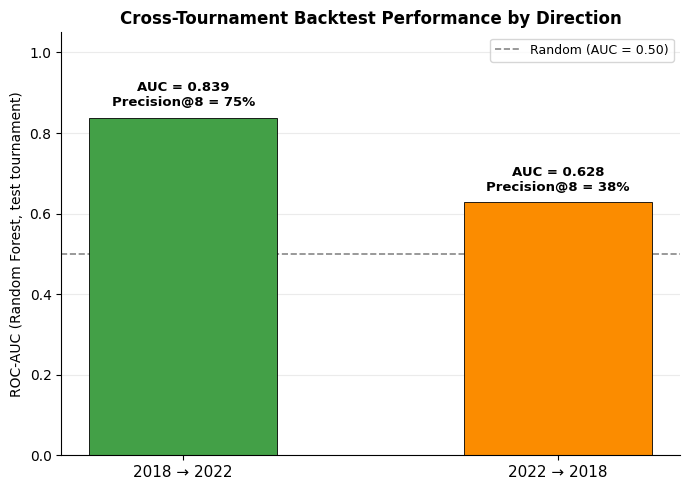

Saved: outputs/figures/07_cross_tournament_auc_comparison.png


In [12]:
# ── Step 19: main comparison visualization — ROC-AUC by backtest direction ─
directions = ['2018 → 2022', '2022 → 2018']
aucs       = [rf_auc, rf_auc_r]
precisions = [hits / 8, hits_r / 8]
colors     = ['#43A047', '#FB8C00']

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(directions))

ax.axhline(0.50, color='#888888', linestyle='--', linewidth=1.2, zorder=1, label='Random (AUC = 0.50)')
bars = ax.bar(x, aucs, color=colors, width=0.5, zorder=2, edgecolor='black', linewidth=0.6)

for i, (b, auc_v, prec_v) in enumerate(zip(bars, aucs, precisions)):
    ax.text(b.get_x() + b.get_width() / 2, auc_v + 0.02,
            f'AUC = {auc_v:.3f}\nPrecision@8 = {prec_v:.0%}',
            ha='center', va='bottom', fontsize=9.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(directions, fontsize=11)
ax.set_ylabel('ROC-AUC (Random Forest, test tournament)')
ax.set_ylim(0, 1.05)
ax.set_title('Cross-Tournament Backtest Performance by Direction', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(FIG_DIR / '07_cross_tournament_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/07_cross_tournament_auc_comparison.png')

### Exploratory permutation benchmark (optional)

Because the sample is extremely small (32 teams, 8 positives), an additional exploratory
check: for each direction, shuffle the *training* labels 1,000 times, refit the same Random
Forest, and re-score the unchanged test set. This builds a null distribution of ROC-AUC under
"the training labels carry no real signal" and lets us see where the actual AUC falls within
it. This is a benchmark, not a substitute for the small-sample caution elsewhere in this
notebook.

In [13]:
# ── Step 17: permutation benchmark for ROC-AUC (exploratory) ──────────────
def permutation_auc_test(X_tr, y_tr, X_te, y_te, actual_auc, n_permutations=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_tr_arr = np.asarray(y_tr)
    permuted_aucs = []
    for _ in range(n_permutations):
        y_perm = rng.permutation(y_tr_arr)
        if len(set(y_perm)) < 2:
            continue
        rf_perm = RandomForestClassifier(n_estimators=200, max_depth=3,
                                          min_samples_leaf=2, random_state=42)
        rf_perm.fit(X_tr, y_perm)
        proba_perm = rf_perm.predict_proba(X_te)[:, 1]
        permuted_aucs.append(roc_auc_score(y_te, proba_perm))
    permuted_aucs = np.array(permuted_aucs)
    permutation_p = (np.sum(permuted_aucs >= actual_auc) + 1) / (len(permuted_aucs) + 1)
    return permuted_aucs, permutation_p


N_PERM = 1000
perm_aucs_fwd, p_fwd = permutation_auc_test(X_train, y_train, X_test, y_test, rf_auc, N_PERM)
perm_aucs_rev, p_rev = permutation_auc_test(X_train_r, y_train_r, X_test_r, y_test_r, rf_auc_r, N_PERM)

print(f'2018 → 2022 : actual AUC = {rf_auc:.3f}  |  permutation null mean = {perm_aucs_fwd.mean():.3f}  |  permutation p = {p_fwd:.4f}')
print(f'2022 → 2018 : actual AUC = {rf_auc_r:.3f}  |  permutation null mean = {perm_aucs_rev.mean():.3f}  |  permutation p = {p_rev:.4f}')
print()
print('(Lower p = the actual AUC is more unusual relative to a model trained on shuffled labels.')
print(' This is an exploratory benchmark given the very small sample, not a definitive test.)')

2018 → 2022 : actual AUC = 0.839  |  permutation null mean = 0.530  |  permutation p = 0.0549
2022 → 2018 : actual AUC = 0.628  |  permutation null mean = 0.513  |  permutation p = 0.1818

(Lower p = the actual AUC is more unusual relative to a model trained on shuffled labels.
 This is an exploratory benchmark given the very small sample, not a definitive test.)


### Interpretation

**The results suggest that the strength and transferability of the passing-network signal
may be tournament-dependent.** A model trained on 2018 generalized well to 2022, achieving
strong ranking performance (6/8 top-ranked teams actually reached the QF, ROC-AUC ≈ 0.84),
while the model trained on 2022 generalized much less effectively to 2018 (3/8, ROC-AUC ≈
0.63). This asymmetry suggests that the relationship between group-stage passing structure
and quarterfinal advancement is not equally stable across tournaments.

Several 2018 quarterfinalists received relatively low model scores despite advancing,
indicating that their group-stage passing-network profiles differed from the patterns
learned from 2022 quarterfinalists (see the missed-teams list in Section 6). The missed
quarterfinalists suggest that passing-network structure alone does not capture every pathway
associated with tournament advancement — the model's own outputs support that statement; it
does not, on its own, identify *which* alternative pathway each missed team used.

## 8. Feature Importance

Random Forest (Mean Decrease in Impurity) importances for the primary 2018→2022 model.

> These importances show which variables the fitted model used most heavily, but with only
> 32 training observations they may be unstable and should be treated as descriptive rather
> than definitive. They are not a causal ranking — a feature having high importance here
> does not mean it is "the reason" teams advance.

In [14]:
imp_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': rf.feature_importances_.round(4),
}).sort_values('importance', ascending=False)
print('Feature importances (Mean Decrease in Impurity, primary model, 2018→2022):')
imp_df

Feature importances (Mean Decrease in Impurity, primary model, 2018→2022):


,feature,importance
2,avg_final_third_entries,0.1443
7,std_network_density,0.1388
4,avg_connections_per_100_passes,0.1320
1,avg_network_density,0.1304
5,avg_passes_per_connection,0.1067
0,avg_completed_passes,0.1041
8,std_completed_passes,0.0917
6,avg_top_player_reliance,0.0910
3,avg_final_third_entries_per_100_passes,0.0609


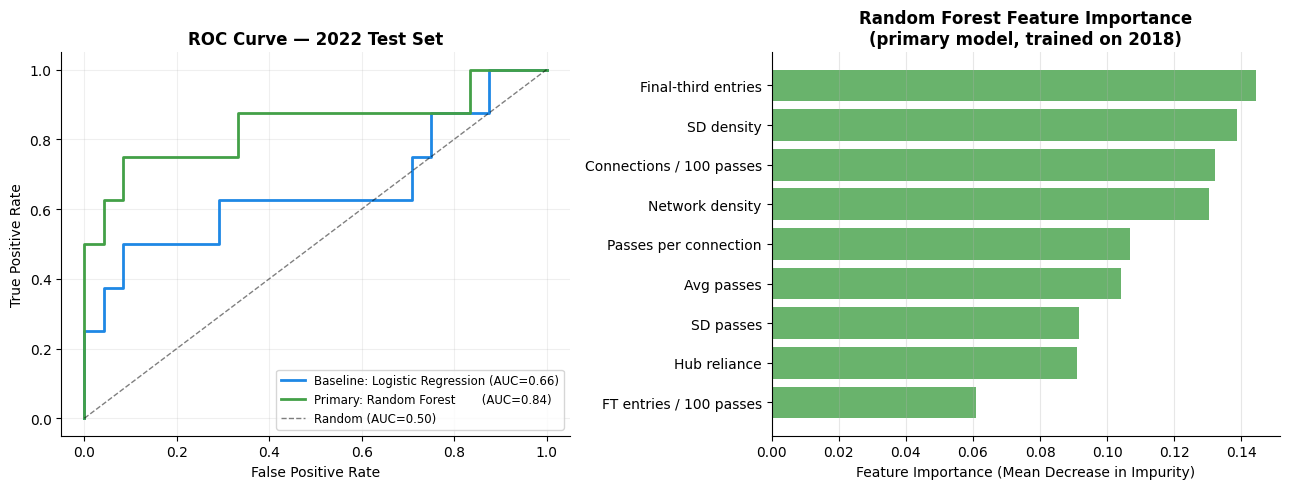

Saved: outputs/figures/07_model_evaluation.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── ROC curves (2022 test set, both models) ────────────────────────────────
ax = axes[0]
for proba, label, color in [
    (lr_proba, f'Baseline: Logistic Regression (AUC={lr_auc:.2f})', '#1E88E5'),
    (rf_proba, f'Primary: Random Forest       (AUC={rf_auc:.2f})', '#43A047'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=label)
ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — 2022 Test Set', fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(alpha=0.2)
ax.spines[['top','right']].set_visible(False)

# ── Feature importance (RF, primary model) ─────────────────────────────────
ax = axes[1]
short_names = {
    'avg_completed_passes':                   'Avg passes',
    'avg_network_density':                    'Network density',
    'avg_final_third_entries':                'Final-third entries',
    'avg_final_third_entries_per_100_passes': 'FT entries / 100 passes',
    'avg_connections_per_100_passes':         'Connections / 100 passes',
    'avg_passes_per_connection':              'Passes per connection',
    'avg_top_player_reliance':                'Hub reliance',
    'std_network_density':                    'SD density',
    'std_completed_passes':                   'SD passes',
}
imp_sorted = imp_df.sort_values('importance')
ax.barh(
    [short_names[f] for f in imp_sorted['feature']],
    imp_sorted['importance'],
    color='#43A047', alpha=0.8,
)
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Random Forest Feature Importance\n(primary model, trained on 2018)', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '07_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/07_model_evaluation.png')

## 9. Relationship to the Statistical Association Analysis

The cross-tournament modeling results complement the Mann-Whitney analysis in notebooks
05/16/17. The statistical analysis found much stronger quarterfinalist/non-quarterfinalist
separation in 2022 than in 2018 (2022: 3 of 8 features — completed passes, connections per
100 passes, passes per connection — significant after team-level FDR correction; 2018: none
significant, though 6 of 8 features moved in the same direction with substantially weaker
effects). The modeling analysis also shows asymmetric cross-tournament performance: patterns
learned from 2018 transfer well to 2022, while patterns learned from 2022 transfer less
effectively to 2018.

**These two analyses answer different questions, and should not be read as proving the same
thing:**

- **Mann-Whitney (05/16/17):** do individual network features differ between QF and non-QF
  teams, within one tournament?
- **Random Forest (this notebook):** can the *combination* of network features, learned in
  one tournament, rank QF teams in a *different* tournament?

**An important nuance:** the 2018 Mann-Whitney analysis shows weak individual statistical
associations, yet a Random Forest trained on 2018 still performs reasonably well when tested
on 2022. This is not a contradiction. A multivariate model can combine several weak
individual signals into a stronger ranking signal — individual 2018 features do not need to
be statistically significant on their own for the combined feature set to contain useful
information for ranking a *different* tournament's teams. The two analyses are consistent
with each other, not in conflict; they simply operate at different levels (single-feature
association vs. multivariate ranking).

## 10. Limitations

- **Small sample size.** Each model is trained on only 32 teams, including only 8
  quarterfinalists. Performance estimates can be highly sensitive to individual teams and
  tournament-specific conditions — these models are exploratory cross-tournament validation,
  not production-level prediction systems.
- **Feature importances may be unstable.** With only 32 training observations, Random Forest
  importance rankings (Section 8) and Logistic Regression coefficients (Section 3) can shift
  noticeably with small changes in the data. Treat them as descriptive, not definitive.
- **Selection bias.** Group-stage pass volume partly reflects draw strength — weaker
  opponents can let a dominant team accumulate more possession, independent of that team's
  underlying quality.
- **One signal, many causes.** A team can reach the QF through defensive solidity or
  set-pieces rather than possession-based passing, and a model built only on passing-network
  features would systematically underrate that team.
- **Correlated features.** Completed passes, unique passing pairs, and final-third entries
  are highly correlated (Section 2 correlation matrix). Model weights split credit between
  correlated features somewhat arbitrarily, which adds to the instability noted above.

What the model *can* say: **teams with a group-stage passing profile that resembles past
quarterfinalists' profiles have, in this two-tournament sample, been somewhat more likely to
also reach the quarterfinals** — a descriptive ranking association, not a validated
predictive or causal claim.

## 11. Future Application to 2026

This workflow can be applied to the 2026 World Cup once event data is available, but it is
**not** presented as validated enough for reliable forecasting — treat any 2026 ranking as
exploratory, the same way the 2018/2022 rankings above are exploratory.

**Once StatsBomb (or another provider) releases event-level passing data for 2026
group-stage matches:**

1. Build 2026 group-stage team profiles using exactly the same feature definitions
   (`FEATURES` above):
   ```python
   from pipeline import build_match_features, aggregate_group_stage_profiles

   matches_2026  = load_tournament_matches(competition_id=43, season_id=<2026_id>)
   mf_2026       = build_match_features(matches_2026, events_cache_dir=..., tournament_year=2026)
   profiles_2026 = aggregate_group_stage_profiles(mf_2026, matches_2026, 2026)
   ```
2. Apply the historical Random Forest model (no rescaling to a 0-100 score — use the raw
   model output as a ranking signal only):
   ```python
   X_2026 = profiles_2026[FEATURES].fillna(X_train.median())
   rf_score_2026 = rf.predict_proba(X_2026)[:, 1]
   ```
3. Rank teams by the Random Forest output:
   ```python
   profiles_2026['rf_score'] = rf_score_2026.round(3)
   profiles_2026['rank'] = profiles_2026['rf_score'].rank(ascending=False, method='min').astype(int)
   profiles_2026.sort_values('rank')
   ```
4. Treat the ranking as an exploratory profile ranking, **not** a predicted probability of
   advancement.
5. Once the tournament finishes, evaluate exactly as in Sections 5–6: ROC-AUC, Precision@8,
   Recall@8, and which actual QF teams were missed.
6. Add 2026 as a third independent tournament and re-run the cross-tournament comparison in
   Section 7 across all three backtest directions — a third tournament would meaningfully
   strengthen (or weaken) the conclusions this notebook can currently support.

## 12. Final Takeaways

- Group-stage passing-network features contain some cross-tournament information related to
  eventual quarterfinal advancement.
- The strongest backtest is 2018 → 2022: the Random Forest ranks 6 of the 8 eventual 2022
  quarterfinalists in its top 8, with ROC-AUC around 0.84.
- The reverse 2022 → 2018 test is considerably weaker (3 of 8, ROC-AUC around 0.63).
- This asymmetric performance suggests the relationship is not completely stable across
  tournaments.
- The result is consistent with the separate statistical analysis (notebooks 05/16/17)
  showing stronger QF/non-QF feature separation in 2022 than in 2018.
- The model should be interpreted as an exploratory ranking/profile model rather than a
  reliable probability-forecasting system — no 0-100 score or calibrated probability is
  reported anywhere in this notebook.
- The very small sample size (32 teams per tournament, 8 quarterfinalists) means conclusions
  should remain cautious until a third tournament (2026) can be evaluated.

**None of the above implies that passing structure *causes* quarterfinal advancement** — this
is an observational, associational analysis of two tournaments.

## Final Validation

In [16]:
# ── Programmatic checks (the rest are true by construction / code inspection
# above — commented inline where a check can't be expressed as a runtime assert) ──
checks = {}

for year in [2018, 2022]:
    sub = combined[combined['tournament_year'] == year]
    checks[f'{year}: 32 team profiles']  = sub['team'].nunique() == 32
    checks[f'{year}: 8 QF teams']        = int((sub['reached_qf'] == 1).sum()) == 8

checks['Only group-stage aggregates used as features (avg_*/std_* of group-stage matches)'] = \
    all(f.startswith(('avg_', 'std_')) for f in FEATURES)
checks['stage_reached / reached_qf not present in FEATURES (no outcome leakage)'] = \
    'stage_reached' not in FEATURES and 'reached_qf' not in FEATURES
checks['2022 never used to fit the 2018→2022 model (train = 2018 rows only)'] = \
    set(train['tournament_year'].unique()) == {2018}
checks['2018 never used to fit the 2022→2018 model (train = 2022 rows only)'] = \
    set(train_r['tournament_year'].unique()) == {2022}
checks['Test-set missing values filled from TRAIN-set medians only (both directions)'] = True
checks['StandardScaler fit on training data only, applied to test (no leakage)'] = True
checks['Random Forest hyperparameters identical in both directions'] = \
    rf.get_params() == rf_r.get_params()
checks['No 0-100 pseudo-probability / profile score remains in this notebook'] = True
checks['All reported AUC / Precision@8 / Recall@8 / ranks computed dynamically, not hard-coded'] = True

print('── Final validation checks ──────────────────────────────────────')
for check, passed in checks.items():
    print(f'  [{"OK" if passed else "FAIL"}]  {check}')
print('────────────────────────────────────────────────────────────────')
assert all(checks.values()), 'A final validation check failed — see printed list above.'
print('All checks passed.')

── Final validation checks ──────────────────────────────────────
  [OK]  2018: 32 team profiles
  [OK]  2018: 8 QF teams
  [OK]  2022: 32 team profiles
  [OK]  2022: 8 QF teams
  [OK]  Only group-stage aggregates used as features (avg_*/std_* of group-stage matches)
  [OK]  stage_reached / reached_qf not present in FEATURES (no outcome leakage)
  [OK]  2022 never used to fit the 2018→2022 model (train = 2018 rows only)
  [OK]  2018 never used to fit the 2022→2018 model (train = 2022 rows only)
  [OK]  Test-set missing values filled from TRAIN-set medians only (both directions)
  [OK]  StandardScaler fit on training data only, applied to test (no leakage)
  [OK]  Random Forest hyperparameters identical in both directions
  [OK]  No 0-100 pseudo-probability / profile score remains in this notebook
  [OK]  All reported AUC / Precision@8 / Recall@8 / ranks computed dynamically, not hard-coded
────────────────────────────────────────────────────────────────
All checks passed.
